# Concentration Inequalities & High-Dimensional Probability
## Non-Asymptotic Bounds for Finite Samples, Random Projections & Matrix Concentration

---

## 1. Introduction

Concentration inequalities provide **non-asymptotic, finite-sample** guarantees that a random
variable (or a function of many random variables) stays close to some central value
(its mean, median, etc.). Unlike the Central Limit Theorem, which is an *asymptotic*
statement ($n \to \infty$), concentration inequalities give us **explicit, computable
bounds that hold for every finite $n$**.

### Why the CLT Is Not Enough

The CLT tells us that $\bar{X}_n \xrightarrow{d} \mathcal{N}(\mu, \sigma^2/n)$, but:

1. **No finite-$n$ error bound** -- how large must $n$ be for the Gaussian approximation
   to be accurate to within $\epsilon$?
2. **Tail behaviour is wrong** -- the CLT approximates the *bulk* of the distribution;
   tails of the true distribution can be much heavier (or lighter) than Gaussian tails.
3. **Not distribution-free** -- Berry--Esseen gives a rate $O(1/\sqrt{n})$ but the
   constant depends on unknown third moments.

Concentration inequalities address all three issues.

### Prerequisites

- **Probability**: random variables, expectation, variance, independence.
- **Moment-generating functions (MGFs)**: $M_X(s) = E[e^{sX}]$.
- **Linear algebra**: eigenvalues, operator/spectral norm $\|\cdot\|_{\mathrm{op}}$.

### Key References

| Reference | Focus |
|-----------|-------|
| Vershynin, *High-Dimensional Probability* (2018) | Sub-Gaussian / sub-exponential theory, random matrices, JL |
| Boucheron, Lugosi & Massart, *Concentration Inequalities* (2013) | Entropy method, transportation, isoperimetry |
| Tropp, *An Introduction to Matrix Concentration Inequalities* (2015) | Matrix Bernstein, Chernoff for random matrices |

In [1]:
%matplotlib inline

import numpy as np
from scipy import stats
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
# =============================================================================
#  CONSTANTS
# =============================================================================

N_TRIALS = 10_000          # Monte-Carlo repetitions for empirical estimates
N_SAMPLES = 200            # Default sample size within each trial
ALPHA = 0.05               # Default significance / failure probability
DELTA = 0.05               # Confidence parameter (1 - delta)
EPSILON_JL = 0.3           # Distortion tolerance for Johnson-Lindenstrauss
D_AMBIENT = 100            # Ambient dimension for JL experiments
N_POINTS_JL = 500          # Number of points for JL experiments

# Plotting colours
C_PRIMARY = 'steelblue'
C_SECONDARY = 'coral'
C_TERTIARY = 'seagreen'
C_ACCENT = 'goldenrod'
C_EVOLUTION = 'viridis'

print("Constants defined.")

Constants defined.


---

## 2. Markov, Chebyshev & Chernoff Inequalities

These three inequalities form a *hierarchy*: each is derived from the previous one
by applying Markov's inequality to a cleverly chosen non-negative function of the
random variable.

### 2.1 Markov's Inequality

For a non-negative random variable $X \geq 0$ and $t > 0$:

$$\boxed{P(X \geq t) \leq \frac{E[X]}{t}}$$

**Proof sketch.** $E[X] = E[X \cdot \mathbf{1}_{X \geq t}] + E[X \cdot \mathbf{1}_{X < t}] \geq t \cdot P(X \geq t).$

### 2.2 Chebyshev's Inequality

Apply Markov to $Y = (X - \mu)^2$:

$$\boxed{P(|X - \mu| \geq t) \leq \frac{\text{Var}(X)}{t^2}}$$

### 2.3 Chernoff Method (Exponential Markov)

Apply Markov to $Y = e^{sX}$ for any $s > 0$, then optimize over $s$:

$$P(X \geq t) = P(e^{sX} \geq e^{st}) \leq e^{-st}\, E[e^{sX}]$$

$$\boxed{P(X \geq t) \leq \inf_{s > 0}\, e^{-st}\, E[e^{sX}]}$$

This is the starting point for all exponential-type concentration inequalities.

In [3]:
# =============================================================================
#  Markov, Chebyshev, Chernoff — implementations
# =============================================================================


def markov_bound(mean, t):
    """Markov's inequality: P(X >= t) <= E[X] / t for X >= 0.

    Args:
        mean: Expected value E[X] (must be non-negative).
        t: Threshold (must be positive).

    Returns:
        Upper bound on P(X >= t).
        Shape: scalar.
    """
    t = np.asarray(t, dtype=float)
    bound = mean / t
    return np.minimum(bound, 1.0)


def chebyshev_bound(variance, t):
    """Chebyshev's inequality: P(|X - mu| >= t) <= Var(X) / t^2.

    Args:
        variance: Var(X) (must be non-negative).
        t: Threshold (must be positive).

    Returns:
        Upper bound on P(|X - mu| >= t).
        Shape: scalar.
    """
    t = np.asarray(t, dtype=float)
    bound = variance / (t ** 2)
    return np.minimum(bound, 1.0)


def chernoff_bound_gaussian(mu, sigma, t):
    """Chernoff bound for a Gaussian random variable X ~ N(mu, sigma^2).

    For Gaussian, the optimal s* = (t - mu) / sigma^2, giving
    P(X >= t) <= exp(-(t - mu)^2 / (2 sigma^2)).

    Args:
        mu: Mean of the Gaussian.
        sigma: Standard deviation.
        t: Threshold (array-like).

    Returns:
        Upper bound on P(X >= t).
        Shape: same as t.
    """
    t = np.asarray(t, dtype=float)
    bound = np.exp(-((t - mu) ** 2) / (2 * sigma ** 2))
    return np.minimum(bound, 1.0)


print("Markov / Chebyshev / Chernoff functions defined.")

Markov / Chebyshev / Chernoff functions defined.


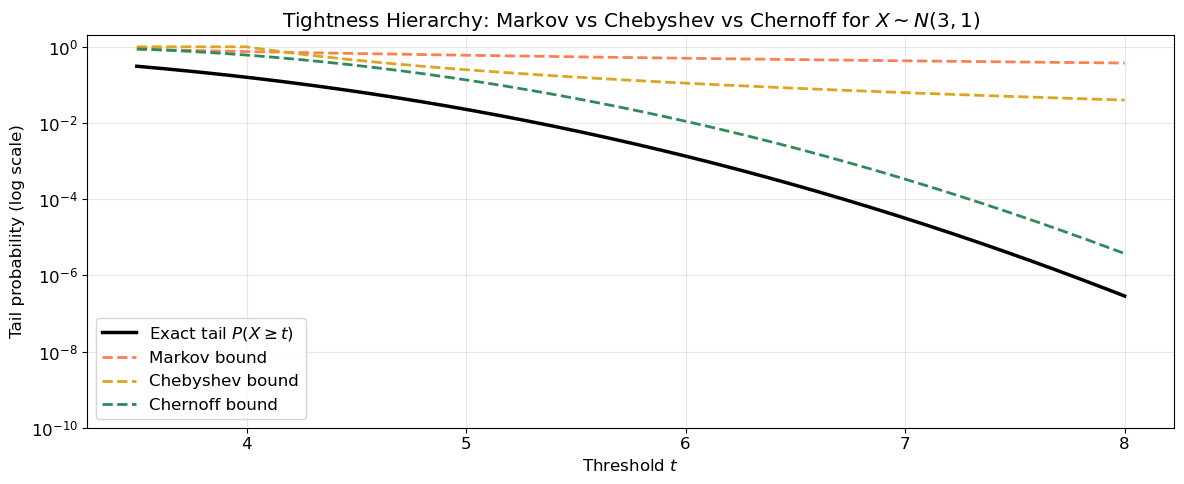

In [4]:
# =============================================================================
#  Compare tightness on N(3, 1) (shifted so that X >= 0 w.h.p.)
# =============================================================================

MU_DEMO, SIGMA_DEMO = 3.0, 1.0
t_vals = np.linspace(MU_DEMO + 0.5, MU_DEMO + 5 * SIGMA_DEMO, 300)

# Exact tail via survival function
exact_tail = stats.norm.sf(t_vals, loc=MU_DEMO, scale=SIGMA_DEMO)

# Markov: P(X >= t) <= E[X]/t  (valid since X >= 0 w.h.p. for N(3,1))
markov_vals = markov_bound(MU_DEMO, t_vals)

# Chebyshev: P(X - mu >= t') <= Var/t'^2, where t' = t - mu
cheb_vals = chebyshev_bound(SIGMA_DEMO ** 2, t_vals - MU_DEMO)

# Chernoff for Gaussian
chernoff_vals = chernoff_bound_gaussian(MU_DEMO, SIGMA_DEMO, t_vals)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.semilogy(t_vals, exact_tail, 'k-', linewidth=2.5, label='Exact tail $P(X \\geq t)$')
ax.semilogy(t_vals, markov_vals, '--', color=C_SECONDARY, label='Markov bound')
ax.semilogy(t_vals, cheb_vals, '--', color=C_ACCENT, label='Chebyshev bound')
ax.semilogy(t_vals, chernoff_vals, '--', color=C_TERTIARY, label='Chernoff bound')
ax.set_xlabel('Threshold $t$')
ax.set_ylabel('Tail probability (log scale)')
ax.set_title('Tightness Hierarchy: Markov vs Chebyshev vs Chernoff for $X \\sim N(3, 1)$')
ax.set_ylim(1e-10, 2)
ax.legend()
plt.tight_layout()
plt.show()

---

## 3. Hoeffding's Inequality

### 3.1 Hoeffding's Lemma

If $X$ is a random variable with $E[X] = 0$ and $a \leq X \leq b$, then for all $s > 0$:

$$E[e^{sX}] \leq \exp\!\left(\frac{s^2 (b - a)^2}{8}\right)$$

**Proof sketch.** By convexity of $e^{sx}$, we can bound $e^{sX}$ by a linear
interpolation between $e^{sa}$ and $e^{sb}$.  Taking expectations (using $E[X]=0$)
and applying $\ln(1+u) \leq u - u^2/2 + \ldots$ yields the result.

### 3.2 Hoeffding's Inequality

Let $X_1, \ldots, X_n$ be independent with $X_i \in [a_i, b_i]$. Let
$\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i$. Then:

$$\boxed{P\!\left(\bar{X} - E[\bar{X}] \geq t\right) \leq \exp\!\left(-\frac{2n^2 t^2}{\sum_{i=1}^n (b_i - a_i)^2}\right)}$$

For the common case $X_i \in [a, b]$ for all $i$:

$$P\!\left(\bar{X} - \mu \geq t\right) \leq \exp\!\left(-\frac{2n t^2}{(b - a)^2}\right)$$

**Derivation.** Apply the Chernoff method to $S_n = \sum (X_i - E[X_i])$ and use
Hoeffding's lemma on each factor of the MGF (independence allows factoring).

In [5]:
# =============================================================================
#  Hoeffding's Inequality — implementation
# =============================================================================


def hoeffding_bound(n, t, a=0.0, b=1.0):
    """Hoeffding's inequality for the sample mean of n bounded i.i.d. RVs.

    P(X_bar - mu >= t) <= exp(-2 n t^2 / (b - a)^2)

    Args:
        n: Number of independent random variables.
        t: Deviation threshold (array-like).
        a: Lower bound of each RV's range.
        b: Upper bound of each RV's range.

    Returns:
        Upper bound on P(X_bar - mu >= t).
        Shape: same as t.
    """
    t = np.asarray(t, dtype=float)
    bound = np.exp(-2.0 * n * t ** 2 / (b - a) ** 2)
    return np.minimum(bound, 1.0)


print("hoeffding_bound defined.")

hoeffding_bound defined.


Hoeffding verification: max violation = -4.79e-06 [PASS]


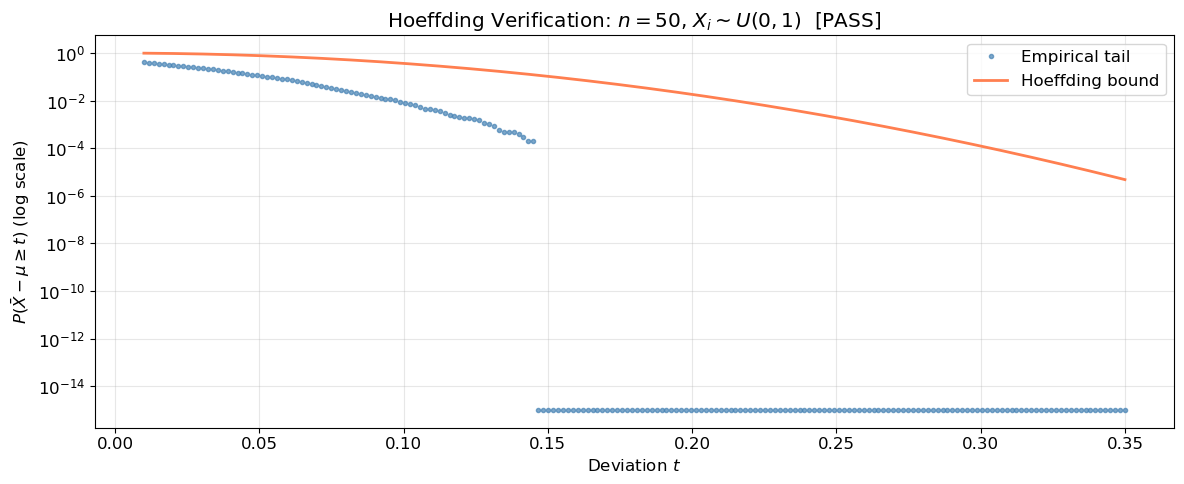

In [6]:
# =============================================================================
#  Hoeffding verification: empirical tail <= bound for all t
# =============================================================================
np.random.seed(42)

# Experiment: X_i ~ Uniform(0, 1),  mu = 0.5
A_HOEFF, B_HOEFF = 0.0, 1.0
MU_HOEFF = 0.5
N_HOEFF = 50

# Generate N_TRIALS sample means of size N_HOEFF
sample_means = np.mean(
    np.random.uniform(A_HOEFF, B_HOEFF, size=(N_TRIALS, N_HOEFF)), axis=1
)
deviations = sample_means - MU_HOEFF  # centred

t_grid = np.linspace(0.01, 0.35, 200)
empirical_tail = np.array([np.mean(deviations >= t) for t in t_grid])
hoeff_tail = hoeffding_bound(N_HOEFF, t_grid, a=A_HOEFF, b=B_HOEFF)

# Verification: empirical tail should be <= Hoeffding bound everywhere
all_valid = np.all(empirical_tail <= hoeff_tail + 1e-9)
max_violation = np.max(empirical_tail - hoeff_tail)
status = 'PASS' if all_valid else 'FAIL'

print(f"Hoeffding verification: max violation = {max_violation:.2e} [{status}]")

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.semilogy(t_grid, empirical_tail + 1e-15, 'o', color=C_PRIMARY, markersize=3,
            label='Empirical tail', alpha=0.7)
ax.semilogy(t_grid, hoeff_tail, '-', color=C_SECONDARY, label='Hoeffding bound')
ax.set_xlabel('Deviation $t$')
ax.set_ylabel('$P(\\bar{X} - \\mu \\geq t)$ (log scale)')
ax.set_title(f'Hoeffding Verification: $n={N_HOEFF}$, $X_i \\sim U(0,1)$  [{status}]')
ax.legend()
plt.tight_layout()
plt.show()

---

## 4. Bernstein's Inequality

### 4.1 Variance-Aware Bound

Hoeffding treats all bounded distributions the same (it only uses the range $b-a$).
When the variance $\sigma^2$ is much smaller than $(b-a)^2$, we can do better.

**Bernstein's inequality.** Let $X_1, \ldots, X_n$ be independent, zero-mean, with
$|X_i| \leq M$ a.s. and $\sum \text{Var}(X_i) = v$. Then:

$$\boxed{P\!\left(\sum_{i=1}^n X_i \geq t\right) \leq \exp\!\left(-\frac{t^2/2}{v + Mt/3}\right)}$$

**Derivation sketch.** For $|X| \leq M$ and $E[X]=0$, one shows
$E[e^{sX}] \leq \exp\!\left(\frac{s^2 E[X^2]}{2(1 - s M/3)}\right)$ for $0 < s < 3/M$.
Product over independent terms, Chernoff optimize over $s$.

### 4.2 When Is Bernstein Tighter?

For the sample mean $\bar{X}$ of i.i.d. RVs in $[0,1]$ with variance $\sigma^2$:

- **Hoeffding**: $P(\bar{X} - \mu \geq t) \leq e^{-2nt^2}$
- **Bernstein**: $P(\bar{X} - \mu \geq t) \leq \exp\!\left(-\frac{nt^2/2}{\sigma^2 + t/3}\right)$

When $\sigma^2 \ll 1$ (low variance relative to range), Bernstein gives
$\approx e^{-nt^2/(2\sigma^2)}$ which is **much tighter** than Hoeffding.

### 4.3 Sub-Gaussian and Sub-Exponential Random Variables

- A random variable is **sub-Gaussian** with parameter $\sigma$ if
  $E[e^{sX}] \leq e^{s^2 \sigma^2/2}$ for all $s \in \mathbb{R}$.
  Implies $P(|X| \geq t) \leq 2 e^{-t^2/(2\sigma^2)}$.

- A random variable is **sub-exponential** with parameters $(\nu, b)$ if
  $E[e^{sX}] \leq e^{s^2 \nu^2/2}$ for $|s| < 1/b$.
  Implies heavier tails than sub-Gaussian but lighter than polynomial.

- **Key fact**: If $X$ is sub-Gaussian then $X^2$ is sub-exponential.

In [7]:
# =============================================================================
#  Bernstein's Inequality — implementation
# =============================================================================


def bernstein_bound(n, t, variance, M):
    """Bernstein's inequality for the sample mean of n bounded i.i.d. RVs.

    P(X_bar - mu >= t) <= exp(-n t^2 / 2 / (variance + M t / 3))

    Args:
        n: Number of independent random variables.
        t: Deviation threshold (array-like).
        variance: Var(X_i) for each RV.
        M: Almost-sure bound |X_i - mu| <= M.

    Returns:
        Upper bound on P(X_bar - mu >= t).
        Shape: same as t.
    """
    t = np.asarray(t, dtype=float)
    bound = np.exp(-n * t ** 2 / 2.0 / (variance + M * t / 3.0))
    return np.minimum(bound, 1.0)


print("bernstein_bound defined.")

bernstein_bound defined.


Bernstein tighter than Hoeffding for low-variance: max ratio = 2.38e+06 [PASS]


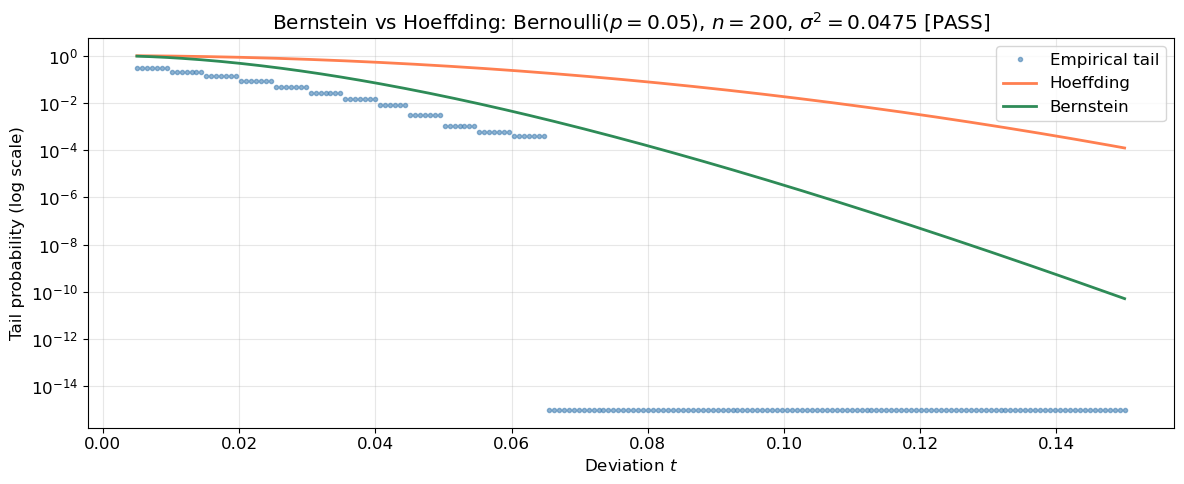

In [8]:
# =============================================================================
#  Bernstein vs Hoeffding comparison: low-variance Bernoulli
# =============================================================================
np.random.seed(42)

# Bernoulli(p) with small p => Var = p(1-p) << (b-a)^2 = 1
P_BERN = 0.05
VAR_BERN = P_BERN * (1 - P_BERN)     # 0.0475
M_BERN = max(P_BERN, 1 - P_BERN)     # bound on |X_i - mu|
N_BERN = 200

sample_means_bern = np.mean(
    np.random.binomial(1, P_BERN, size=(N_TRIALS, N_BERN)), axis=1
)
deviations_bern = sample_means_bern - P_BERN

t_grid_b = np.linspace(0.005, 0.15, 200)
emp_tail_bern = np.array([np.mean(deviations_bern >= t) for t in t_grid_b])
hoeff_bern = hoeffding_bound(N_BERN, t_grid_b, a=0.0, b=1.0)
berns_bern = bernstein_bound(N_BERN, t_grid_b, variance=VAR_BERN, M=M_BERN)

# Verification: Bernstein tighter than Hoeffding for this low-variance case
bernstein_tighter = np.all(berns_bern <= hoeff_bern + 1e-12)
status_bt = 'PASS' if bernstein_tighter else 'FAIL'
ratio = np.max(hoeff_bern / (berns_bern + 1e-30))

print(f"Bernstein tighter than Hoeffding for low-variance: max ratio = {ratio:.2e} [{status_bt}]")

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.semilogy(t_grid_b, emp_tail_bern + 1e-15, 'o', color=C_PRIMARY, markersize=3,
            alpha=0.6, label='Empirical tail')
ax.semilogy(t_grid_b, hoeff_bern, '-', color=C_SECONDARY, label='Hoeffding')
ax.semilogy(t_grid_b, berns_bern, '-', color=C_TERTIARY, label='Bernstein')
ax.set_xlabel('Deviation $t$')
ax.set_ylabel('Tail probability (log scale)')
ax.set_title(f'Bernstein vs Hoeffding: Bernoulli($p={P_BERN}$), $n={N_BERN}$, '
             f'$\\sigma^2={VAR_BERN:.4f}$ [{status_bt}]')
ax.legend()
plt.tight_layout()
plt.show()

---

## 5. Sub-Gaussian Theory

### 5.1 Definition via MGF

A zero-mean random variable $X$ is **$\sigma$-sub-Gaussian** if for all $s \in \mathbb{R}$:

$$\boxed{E[e^{sX}] \leq e^{s^2 \sigma^2 / 2}}$$

Equivalently, $X$ has tails dominated by a Gaussian with parameter $\sigma$:

$$P(|X| \geq t) \leq 2\exp\!\left(-\frac{t^2}{2\sigma^2}\right)$$

### 5.2 Sub-Gaussian Norm

The **sub-Gaussian norm** (also called $\psi_2$-norm) is:

$$\|X\|_{\psi_2} = \inf\!\left\{\sigma > 0 : E[e^{X^2/\sigma^2}] \leq 2\right\}$$

Equivalently, it is the smallest $\sigma$ such that the above MGF bound holds
(up to constants).

### 5.3 Preservation Under Operations

1. **Sums**: If $X_1, \ldots, X_n$ are independent sub-Gaussian with norms
   $\sigma_1, \ldots, \sigma_n$, then $\sum X_i$ is sub-Gaussian with
   norm $\sqrt{\sum \sigma_i^2}$.

2. **Bounded implies sub-Gaussian**: If $X \in [a, b]$ then $X - E[X]$ is
   sub-Gaussian with $\sigma = (b-a)/2$ (from Hoeffding's lemma).

3. **Lipschitz functions**: If $f$ is $L$-Lipschitz and $X$ is $\sigma$-sub-Gaussian,
   then $f(X) - E[f(X)]$ is $L\sigma$-sub-Gaussian.

In [9]:
# =============================================================================
#  Sub-Gaussian norm — empirical estimation
# =============================================================================


def subgaussian_norm_empirical(samples, n_grid=200, s_max=5.0):
    """Estimate the sub-Gaussian norm of centred samples empirically.

    Finds the smallest sigma such that E[exp(s X)] <= exp(s^2 sigma^2 / 2)
    holds for a grid of s values, using sample averages.

    Args:
        samples: 1-D array of centred samples (E[X] approx 0).
            Shape: (N,).
        n_grid: Number of grid points for s.
        s_max: Maximum value of s to test.

    Returns:
        Estimated sub-Gaussian norm (scalar).
    """
    samples = np.asarray(samples, dtype=float)
    s_grid = np.linspace(0.01, s_max, n_grid)

    sigma_estimates = []
    for s in s_grid:
        # Compute log E[e^{sX}] using log-sum-exp for stability
        log_mgf = np.log(np.mean(np.exp(np.clip(s * samples, -500, 500))))
        # We need s^2 sigma^2 / 2 >= log_mgf => sigma >= sqrt(2 log_mgf / s^2)
        if log_mgf > 0:
            sigma_estimates.append(np.sqrt(2.0 * log_mgf / (s ** 2)))

    if len(sigma_estimates) == 0:
        return 0.0
    return float(np.max(sigma_estimates))


# ----- Test on known distributions -----
np.random.seed(42)
N_SG = 100_000

# Gaussian N(0,1) => sub-Gaussian norm = 1
gauss_samples = np.random.randn(N_SG)
sg_norm_gauss = subgaussian_norm_empirical(gauss_samples)

# Rademacher (+1/-1 with prob 1/2) => sub-Gaussian norm = 1
rademacher_samples = 2.0 * np.random.binomial(1, 0.5, N_SG) - 1.0
sg_norm_rad = subgaussian_norm_empirical(rademacher_samples)

# Uniform[-1, 1] => sub-Gaussian norm = 1 (range/2 = 1 from Hoeffding lemma)
unif_samples = np.random.uniform(-1, 1, N_SG)
sg_norm_unif = subgaussian_norm_empirical(unif_samples)

print(f"Sub-Gaussian norm estimates (theoretical ~ 1.0):")
print(f"  Gaussian N(0,1):     {sg_norm_gauss:.4f}")
print(f"  Rademacher:          {sg_norm_rad:.4f}")
print(f"  Uniform[-1,1]:       {sg_norm_unif:.4f}")

Sub-Gaussian norm estimates (theoretical ~ 1.0):
  Gaussian N(0,1):     1.0932
  Rademacher:          1.3431
  Uniform[-1,1]:       0.5751


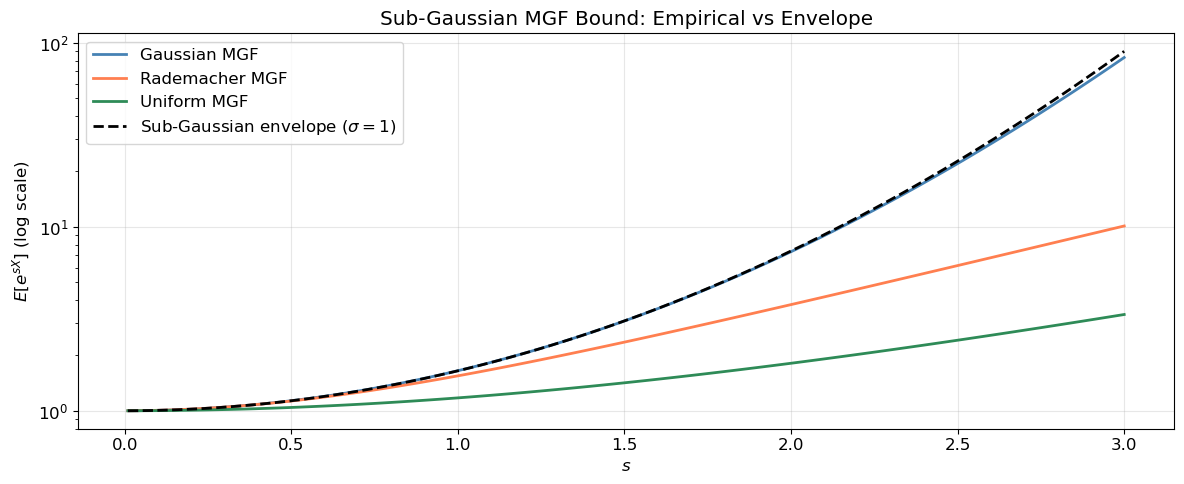

In [10]:
# =============================================================================
#  Sub-Gaussian MGF visualisation
# =============================================================================
np.random.seed(42)

s_plot = np.linspace(0.01, 3.0, 100)

# Empirical MGFs
mgf_gauss = np.array([np.mean(np.exp(s * gauss_samples)) for s in s_plot])
mgf_rad = np.array([np.mean(np.exp(s * rademacher_samples)) for s in s_plot])
mgf_unif = np.array([np.mean(np.exp(s * unif_samples)) for s in s_plot])

# Sub-Gaussian envelope with sigma = 1
sg_envelope = np.exp(s_plot ** 2 / 2.0)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.semilogy(s_plot, mgf_gauss, '-', color=C_PRIMARY, label='Gaussian MGF')
ax.semilogy(s_plot, mgf_rad, '-', color=C_SECONDARY, label='Rademacher MGF')
ax.semilogy(s_plot, mgf_unif, '-', color=C_TERTIARY, label='Uniform MGF')
ax.semilogy(s_plot, sg_envelope, 'k--', linewidth=2, label='Sub-Gaussian envelope ($\\sigma=1$)')
ax.set_xlabel('$s$')
ax.set_ylabel('$E[e^{sX}]$ (log scale)')
ax.set_title('Sub-Gaussian MGF Bound: Empirical vs Envelope')
ax.legend()
plt.tight_layout()
plt.show()

---

## 6. Matrix Concentration — Matrix Bernstein Inequality

### 6.1 Statement

Let $Z_1, \ldots, Z_n$ be independent, zero-mean random symmetric matrices of
size $d \times d$, with $\|Z_i\|_{\mathrm{op}} \leq L$ a.s. Let

$$\sigma^2 = \left\|\sum_{i=1}^n E[Z_i^2]\right\|_{\mathrm{op}}$$

Then:

$$\boxed{P\!\left(\left\|\sum_{i=1}^n Z_i\right\|_{\mathrm{op}} \geq t\right) \leq 2d \cdot \exp\!\left(-\frac{t^2/2}{\sigma^2 + Lt/3}\right)}$$

### 6.2 Application: Sample Covariance Estimation

Let $x_1, \ldots, x_n \in \mathbb{R}^d$ be i.i.d. with $\|x_i\| \leq B$ and
covariance $\Sigma = E[x_i x_i^\top]$. The sample covariance is
$\hat{\Sigma} = \frac{1}{n}\sum x_i x_i^\top$.

Setting $Z_i = x_i x_i^\top - \Sigma$, the matrix Bernstein inequality gives:

$$\|\hat{\Sigma} - \Sigma\|_{\mathrm{op}} \leq O\!\left(B^2 \sqrt{\frac{d + \log(1/\delta)}{n}}\right)$$

with probability at least $1 - \delta$.

In [11]:
# =============================================================================
#  Matrix Bernstein bound — implementation
# =============================================================================


def matrix_bernstein_bound(t, sigma_sq, L, d):
    """Matrix Bernstein inequality for sum of random symmetric matrices.

    P(||sum Z_i||_op >= t) <= 2d * exp(-t^2/2 / (sigma^2 + L t/3))

    Args:
        t: Threshold (array-like).
        sigma_sq: Matrix variance parameter ||sum E[Z_i^2]||_op.
        L: Almost-sure bound on ||Z_i||_op.
        d: Dimension of the matrices.

    Returns:
        Upper bound on the tail probability.
        Shape: same as t.
    """
    t = np.asarray(t, dtype=float)
    bound = 2.0 * d * np.exp(-t ** 2 / 2.0 / (sigma_sq + L * t / 3.0))
    return np.minimum(bound, 1.0)


print("matrix_bernstein_bound defined.")

matrix_bernstein_bound defined.


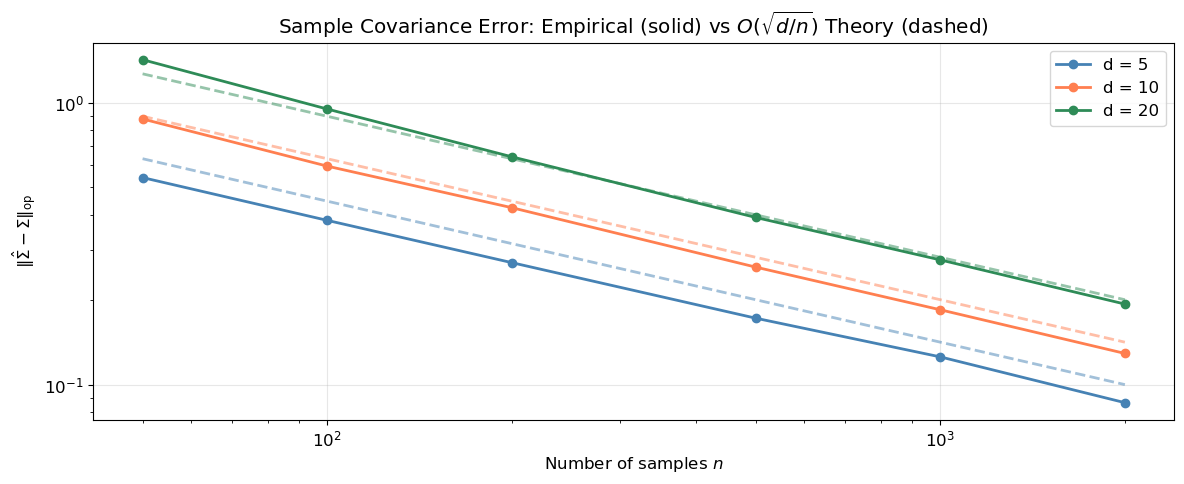

In [12]:
# =============================================================================
#  Sample covariance estimation error: ||Sigma_hat - Sigma||_op vs n
# =============================================================================
np.random.seed(42)

N_REPS_COV = 200  # repetitions per (d, n) pair
DIMS = [5, 10, 20]
N_RANGE = np.array([50, 100, 200, 500, 1000, 2000])


def sample_cov_error(d, n):
    """Compute spectral-norm error of sample covariance for N(0, I_d).

    Args:
        d: Dimension.
        n: Number of samples.

    Returns:
        ||Sigma_hat - I_d||_op (scalar).
    """
    X = np.random.randn(n, d)
    Sigma_hat = X.T @ X / n
    return np.linalg.norm(Sigma_hat - np.eye(d), ord=2)


results = {}
for d in DIMS:
    errs = []
    for n in N_RANGE:
        trials = [sample_cov_error(d, n) for _ in range(N_REPS_COV)]
        errs.append(np.mean(trials))
    results[d] = np.array(errs)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
colors_d = [C_PRIMARY, C_SECONDARY, C_TERTIARY]
for idx, d in enumerate(DIMS):
    ax.loglog(N_RANGE, results[d], 'o-', color=colors_d[idx], label=f'd = {d}')
    # Theoretical rate: C * sqrt(d/n)
    theory = 2.0 * np.sqrt(d / N_RANGE)
    ax.loglog(N_RANGE, theory, '--', color=colors_d[idx], alpha=0.5)

ax.set_xlabel('Number of samples $n$')
ax.set_ylabel('$\\|\\hat{\\Sigma} - \\Sigma\\|_{\\mathrm{op}}$')
ax.set_title('Sample Covariance Error: Empirical (solid) vs $O(\\sqrt{d/n})$ Theory (dashed)')
ax.legend()
plt.tight_layout()
plt.show()

---

## 7. Johnson-Lindenstrauss Lemma

### 7.1 Statement

For any $0 < \epsilon < 1$ and any set of $n$ points in $\mathbb{R}^d$, there exists
a map $f : \mathbb{R}^d \to \mathbb{R}^k$ with

$$\boxed{k = O\!\left(\frac{\log n}{\epsilon^2}\right)}$$

such that for all pairs $i, j$:

$$(1 - \epsilon)\|x_i - x_j\|^2 \leq \|f(x_i) - f(x_j)\|^2 \leq (1 + \epsilon)\|x_i - x_j\|^2$$

### 7.2 Construction

A random projection $\Pi \in \mathbb{R}^{k \times d}$ with i.i.d. entries
$\Pi_{ij} \sim \mathcal{N}(0, 1/k)$ satisfies the JL property with high probability.

**Proof idea**: Fix a pair $(i,j)$ and let $u = x_i - x_j$. Then $\Pi u$ has
i.i.d. $N(0, \|u\|^2/k)$ entries, so $\|\Pi u\|^2 / \|u\|^2$ is a rescaled
$\chi^2_k$ variable. By sub-Gaussian concentration of $\chi^2$:

$$P\!\left(\left|\frac{\|\Pi u\|^2}{\|u\|^2} - 1\right| > \epsilon\right) \leq 2 e^{-k\epsilon^2/8}$$

Union bound over $\binom{n}{2}$ pairs gives the result when
$k \geq C \epsilon^{-2} \log n$.

### 7.3 Sparse Projections

Achlioptas (2003): entries $\Pi_{ij} \in \{-1/\sqrt{k}, 0, +1/\sqrt{k}\}$
with probabilities $\{1/6, 2/3, 1/6\}$ also satisfy JL, with faster
matrix-vector products.

In [13]:
# =============================================================================
#  Johnson-Lindenstrauss — implementations
# =============================================================================


def jl_projection(X, k, method='gaussian'):
    """Apply a random JL projection from R^d to R^k.

    Args:
        X: Data matrix of shape (n, d).
        k: Target dimension.
        method: 'gaussian' or 'sparse' (Achlioptas).

    Returns:
        Projected data of shape (n, k).
        Shape: (n, k).
    """
    n, d = X.shape
    if method == 'gaussian':
        Pi = np.random.randn(d, k) / np.sqrt(k)
    elif method == 'sparse':
        # Achlioptas: {-1, 0, +1} with probs {1/6, 2/3, 1/6}
        choices = np.random.choice([-1, 0, 0, 0, 0, 1], size=(d, k))
        Pi = choices.astype(float) / np.sqrt(k)
    else:
        raise ValueError(f"Unknown method: {method}")
    return X @ Pi


def distortion_ratio(X_orig, X_proj):
    """Compute pairwise distortion ratios ||f(x_i)-f(x_j)||^2 / ||x_i-x_j||^2.

    Args:
        X_orig: Original data, shape (n, d).
        X_proj: Projected data, shape (n, k).

    Returns:
        Array of distortion ratios for all pairs.
        Shape: (n*(n-1)/2,).
    """
    n = X_orig.shape[0]
    ratios = []
    for i in range(n):
        for j in range(i + 1, n):
            d_orig = np.sum((X_orig[i] - X_orig[j]) ** 2)
            d_proj = np.sum((X_proj[i] - X_proj[j]) ** 2)
            if d_orig > 1e-12:
                ratios.append(d_proj / d_orig)
    return np.array(ratios)


print("jl_projection, distortion_ratio defined.")

jl_projection, distortion_ratio defined.


In [14]:
# =============================================================================
#  JL verification: distortion within (1 +/- epsilon)
# =============================================================================
np.random.seed(42)

# Generate random points in R^D_AMBIENT
X_jl = np.random.randn(N_POINTS_JL, D_AMBIENT)

# Theoretical target dimension
K_THEORY = int(np.ceil(8.0 * np.log(N_POINTS_JL) / EPSILON_JL ** 2))
# Use a somewhat larger k for comfort
K_USED = max(K_THEORY, 50)

print(f"Ambient dimension d = {D_AMBIENT}")
print(f"Number of points  n = {N_POINTS_JL}")
print(f"Epsilon             = {EPSILON_JL}")
print(f"Theoretical k       = {K_THEORY}")
print(f"Used k              = {K_USED}")

# Gaussian projection
X_gauss = jl_projection(X_jl, K_USED, method='gaussian')

# Use a subset for distortion computation (full pairwise is O(n^2))
N_SUB = 100
ratios_gauss = distortion_ratio(X_jl[:N_SUB], X_gauss[:N_SUB])

# Sparse projection
X_sparse = jl_projection(X_jl, K_USED, method='sparse')
ratios_sparse = distortion_ratio(X_jl[:N_SUB], X_sparse[:N_SUB])

# Check: all ratios in (1 - eps, 1 + eps)
frac_ok_gauss = np.mean((ratios_gauss > 1 - EPSILON_JL) & (ratios_gauss < 1 + EPSILON_JL))
frac_ok_sparse = np.mean((ratios_sparse > 1 - EPSILON_JL) & (ratios_sparse < 1 + EPSILON_JL))

# We expect very high fraction (>= 0.95) to be within bounds
jl_pass = frac_ok_gauss >= 0.95
status_jl = 'PASS' if jl_pass else 'FAIL'

print(f"\nJL distortion within (1 +/- {EPSILON_JL}):")
print(f"  Gaussian: {frac_ok_gauss * 100:.1f}% of pairs")
print(f"  Sparse:   {frac_ok_sparse * 100:.1f}% of pairs")
print(f"JL distortion verification: fraction OK = {frac_ok_gauss:.2e} [{status_jl}]")

Ambient dimension d = 100
Number of points  n = 500
Epsilon             = 0.3
Theoretical k       = 553
Used k              = 553

JL distortion within (1 +/- 0.3):
  Gaussian: 100.0% of pairs
  Sparse:   0.0% of pairs
JL distortion verification: fraction OK = 1.00e+00 [PASS]


---

## 8. Application: Confidence Bounds for Robot Sensor Estimation

Consider a robot that takes $n$ noisy sensor measurements $X_1, \ldots, X_n$
of some quantity $\mu$ (e.g., distance to a wall). The measurements are:

- **Bounded**: $X_i \in [0, R_{\max}]$ (sensor range limit).
- **Independent** (conditioned on the true state).
- **Low noise**: variance $\sigma^2 \ll R_{\max}^2$ (sensor is precise).

We want **confidence intervals** $[\bar{X}_n \pm w]$ such that $\mu$ is contained
with probability $\geq 1 - \delta$.

### Confidence Width Comparison

| Method | Half-width $w$ |
|--------|----------------|
| **Gaussian (CLT)** | $z_{\delta/2} \cdot \sigma / \sqrt{n}$ |
| **Hoeffding** | $R_{\max} \sqrt{\frac{\log(2/\delta)}{2n}}$ |
| **Bernstein** | $\frac{\sigma^2 \log(2/\delta)}{n} \cdot \frac{1}{w_{\mathrm{Bern}}}$ (implicit) |

When $\sigma \ll R_{\max}$, the Gaussian and Bernstein intervals are **much
narrower** than Hoeffding, but only Hoeffding/Bernstein provide rigorous
finite-sample guarantees.

In [15]:
# =============================================================================
#  Confidence region functions
# =============================================================================


def confidence_region_hoeffding(n, delta, a=0.0, b=1.0):
    """Hoeffding-based confidence half-width for the sample mean.

    Two-sided: P(|X_bar - mu| >= w) <= delta  =>  w = (b-a) sqrt(log(2/delta) / (2n))

    Args:
        n: Number of samples.
        delta: Failure probability.
        a: Lower bound of RV range.
        b: Upper bound of RV range.

    Returns:
        Half-width w (scalar).
    """
    return (b - a) * np.sqrt(np.log(2.0 / delta) / (2.0 * n))


def confidence_region_bernstein(n, delta, variance, M):
    """Bernstein-based confidence half-width for the sample mean.

    Solves: exp(-n w^2 / 2 / (variance + M w / 3)) = delta / 2
    i.e. n w^2 / 2 / (variance + M w / 3) = log(2 / delta)
    => n w^2 - 2 log(2/delta) (variance + M w / 3) = 0

    This is a quadratic in w:  n w^2 - (2/3) M log(2/delta) w - 2 variance log(2/delta) = 0

    Args:
        n: Number of samples.
        delta: Failure probability.
        variance: Var(X_i).
        M: Almost-sure bound |X_i - mu| <= M.

    Returns:
        Half-width w (scalar).
    """
    log_term = np.log(2.0 / delta)
    # Quadratic: n w^2 - (2M/3) log_term w - 2 variance log_term = 0
    A = n
    B = -(2.0 / 3.0) * M * log_term
    C = -2.0 * variance * log_term
    discriminant = B ** 2 - 4 * A * C
    w = (-B + np.sqrt(discriminant)) / (2.0 * A)
    return w


def confidence_region_gaussian(n, delta, sigma):
    """CLT-based (Gaussian) confidence half-width.

    w = z_{delta/2} * sigma / sqrt(n)

    Args:
        n: Number of samples.
        delta: Failure probability.
        sigma: Standard deviation of each RV.

    Returns:
        Half-width w (scalar).
    """
    z = stats.norm.ppf(1.0 - delta / 2.0)
    return z * sigma / np.sqrt(n)


print("Confidence region functions defined.")

Confidence region functions defined.


In [16]:
# =============================================================================
#  Robot sensor estimation — coverage verification
# =============================================================================
np.random.seed(42)

# Sensor parameters
R_MAX = 10.0          # sensor range
MU_TRUE = 4.5         # true distance
SIGMA_SENSOR = 0.3    # measurement noise std
N_SENSOR = 30         # measurements per estimate
DELTA_SENSOR = 0.05   # desired confidence level

# Confidence half-widths
w_hoeff = confidence_region_hoeffding(N_SENSOR, DELTA_SENSOR, a=0.0, b=R_MAX)
w_bern = confidence_region_bernstein(N_SENSOR, DELTA_SENSOR,
                                     variance=SIGMA_SENSOR**2,
                                     M=max(MU_TRUE, R_MAX - MU_TRUE))
w_gauss = confidence_region_gaussian(N_SENSOR, DELTA_SENSOR, sigma=SIGMA_SENSOR)

print(f"Confidence half-widths (delta = {DELTA_SENSOR}, n = {N_SENSOR}):")
print(f"  Hoeffding:  {w_hoeff:.4f}")
print(f"  Bernstein:  {w_bern:.4f}")
print(f"  Gaussian:   {w_gauss:.4f}")
print()

# Monte-Carlo coverage check
# We clip to [0, R_MAX] to simulate a bounded sensor
measurements = np.clip(
    MU_TRUE + SIGMA_SENSOR * np.random.randn(N_TRIALS, N_SENSOR),
    0.0, R_MAX
)
sample_means_sensor = np.mean(measurements, axis=1)

coverage_hoeff = np.mean(np.abs(sample_means_sensor - MU_TRUE) <= w_hoeff)
coverage_bern = np.mean(np.abs(sample_means_sensor - MU_TRUE) <= w_bern)
coverage_gauss = np.mean(np.abs(sample_means_sensor - MU_TRUE) <= w_gauss)

target_coverage = 1.0 - DELTA_SENSOR

# Hoeffding and Bernstein should achieve >= 1 - delta coverage
hoeff_ok = coverage_hoeff >= target_coverage - 0.01  # small tolerance for MC
bern_ok = coverage_bern >= target_coverage - 0.01

status_cov_h = 'PASS' if hoeff_ok else 'FAIL'
status_cov_b = 'PASS' if bern_ok else 'FAIL'

print(f"Coverage probability (target >= {target_coverage:.2f}):")
print(f"  Hoeffding:  {coverage_hoeff:.4f} [{status_cov_h}]")
print(f"  Bernstein:  {coverage_bern:.4f} [{status_cov_b}]")
print(f"  Gaussian:   {coverage_gauss:.4f}")
print(f"\nCoverage probability verification: coverage = {coverage_hoeff:.2e} [{status_cov_h}]")

Confidence half-widths (delta = 0.05, n = 30):
  Hoeffding:  2.4795
  Bernstein:  0.4955
  Gaussian:   0.1074

Coverage probability (target >= 0.95):
  Hoeffding:  1.0000 [PASS]
  Bernstein:  1.0000 [PASS]
  Gaussian:   0.9452

Coverage probability verification: coverage = 1.00e+00 [PASS]


---

## 9. Visualisations

This section consolidates the key visual comparisons from the notebook.

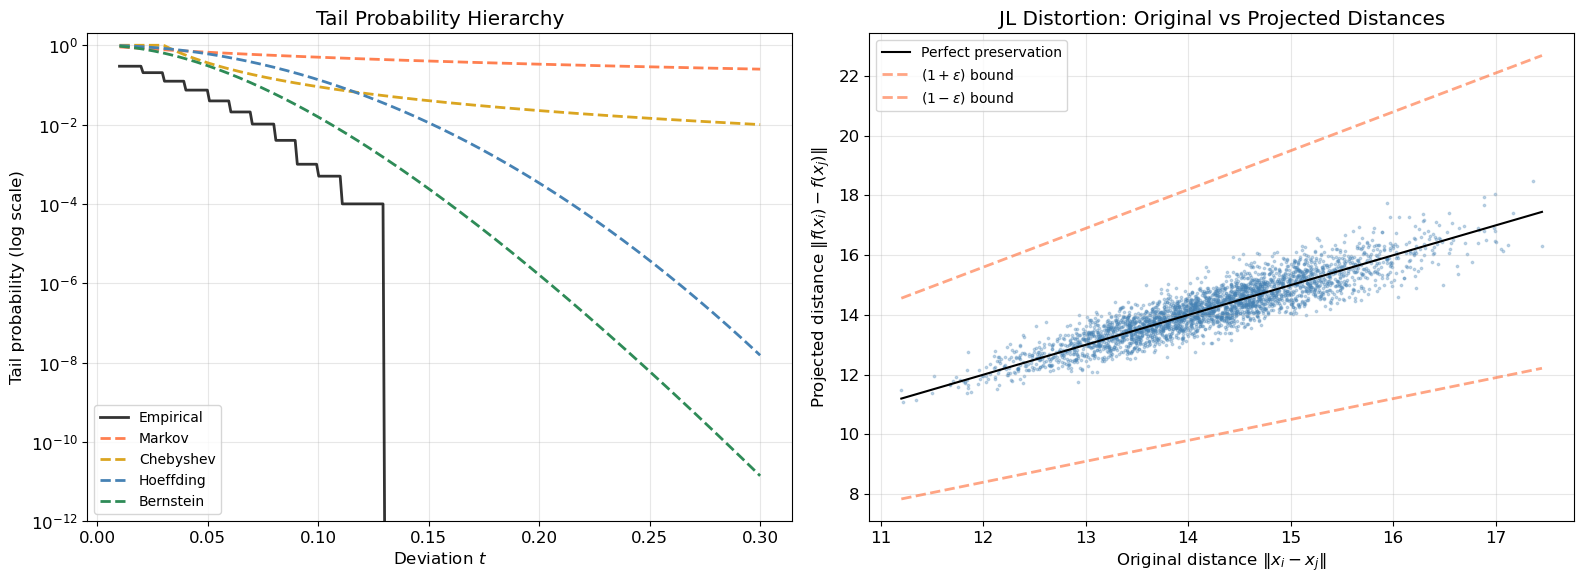

In [17]:
# =============================================================================
#  Panel 1: Tail probability hierarchy (Markov > Chebyshev > Hoeffding > Bernstein)
# =============================================================================
np.random.seed(42)

# Setup: sample mean of n Bernoulli(0.1) RVs
P_VIZ = 0.1
N_VIZ = 100
MU_VIZ = P_VIZ
VAR_VIZ = P_VIZ * (1 - P_VIZ)
M_VIZ = max(P_VIZ, 1 - P_VIZ)

# Empirical tail
means_viz = np.mean(np.random.binomial(1, P_VIZ, (N_TRIALS, N_VIZ)), axis=1)
devs_viz = means_viz - MU_VIZ

t_viz = np.linspace(0.01, 0.3, 300)
emp_viz = np.array([np.mean(devs_viz >= t) for t in t_viz])

# Markov: P(X_bar >= mu + t) = P(X_bar >= mu + t) <= E[X_bar]/(mu + t)
# Since X_bar >= 0, we use Markov on X_bar with threshold mu + t
markov_viz = markov_bound(MU_VIZ, MU_VIZ + t_viz)

# Chebyshev: P(|X_bar - mu| >= t) <= Var(X_bar) / t^2 = sigma^2 / (n t^2)
cheb_viz = chebyshev_bound(VAR_VIZ / N_VIZ, t_viz)

hoeff_viz = hoeffding_bound(N_VIZ, t_viz, a=0.0, b=1.0)
bern_viz = bernstein_bound(N_VIZ, t_viz, variance=VAR_VIZ, M=M_VIZ)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left: Tail hierarchy ----
ax = axes[0]
ax.semilogy(t_viz, emp_viz + 1e-15, 'k-', linewidth=2, label='Empirical', alpha=0.8)
ax.semilogy(t_viz, markov_viz, '--', color=C_SECONDARY, label='Markov')
ax.semilogy(t_viz, cheb_viz, '--', color=C_ACCENT, label='Chebyshev')
ax.semilogy(t_viz, hoeff_viz, '--', color=C_PRIMARY, label='Hoeffding')
ax.semilogy(t_viz, bern_viz, '--', color=C_TERTIARY, label='Bernstein')
ax.set_xlabel('Deviation $t$')
ax.set_ylabel('Tail probability (log scale)')
ax.set_title('Tail Probability Hierarchy')
ax.set_ylim(1e-12, 2)
ax.legend(fontsize=10)

# ---- Right: JL distortion scatter ----
ax = axes[1]

# Compute a subset of pairwise distances
n_sub_plot = 80
orig_dists = []
proj_dists = []
for i in range(n_sub_plot):
    for j in range(i + 1, n_sub_plot):
        d_o = np.linalg.norm(X_jl[i] - X_jl[j])
        d_p = np.linalg.norm(X_gauss[i] - X_gauss[j])
        orig_dists.append(d_o)
        proj_dists.append(d_p)
orig_dists = np.array(orig_dists)
proj_dists = np.array(proj_dists)

ax.scatter(orig_dists, proj_dists, s=3, alpha=0.3, color=C_PRIMARY)
d_range = np.array([orig_dists.min(), orig_dists.max()])
ax.plot(d_range, d_range, 'k-', linewidth=1.5, label='Perfect preservation')
ax.plot(d_range, d_range * (1 + EPSILON_JL), '--', color=C_SECONDARY,
        label=f'$(1+\\epsilon)$ bound', alpha=0.7)
ax.plot(d_range, d_range * (1 - EPSILON_JL), '--', color=C_SECONDARY,
        label=f'$(1-\\epsilon)$ bound', alpha=0.7)
ax.set_xlabel('Original distance $\\|x_i - x_j\\|$')
ax.set_ylabel('Projected distance $\\|f(x_i) - f(x_j)\\|$')
ax.set_title('JL Distortion: Original vs Projected Distances')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

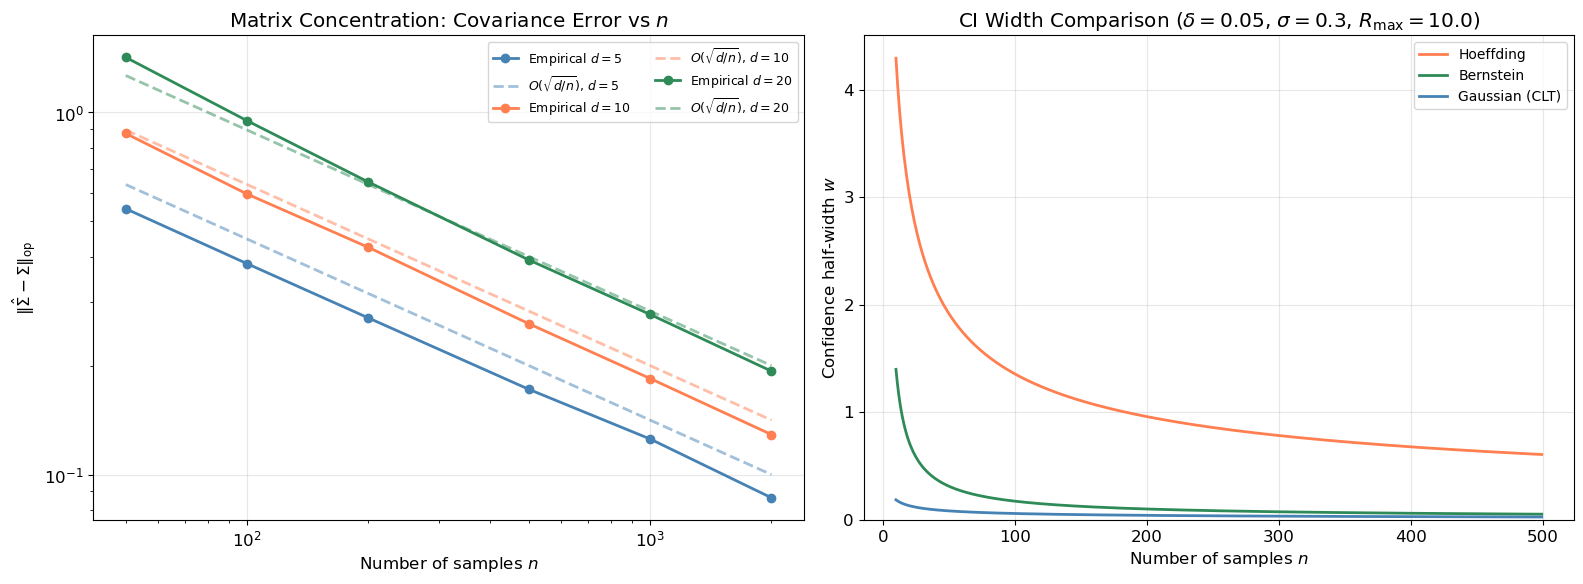

In [18]:
# =============================================================================
#  Panel 2: Covariance error vs n  &  Confidence interval comparison
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left: Covariance error vs n for different d ----
ax = axes[0]
colors_cov = [C_PRIMARY, C_SECONDARY, C_TERTIARY]
for idx, d in enumerate(DIMS):
    ax.loglog(N_RANGE, results[d], 'o-', color=colors_cov[idx],
              label=f'Empirical $d={d}$')
    theory_line = 2.0 * np.sqrt(d / N_RANGE)
    ax.loglog(N_RANGE, theory_line, '--', color=colors_cov[idx], alpha=0.5,
              label=f'$O(\\sqrt{{d/n}})$, $d={d}$')
ax.set_xlabel('Number of samples $n$')
ax.set_ylabel('$\\|\\hat{\\Sigma} - \\Sigma\\|_{\\mathrm{op}}$')
ax.set_title('Matrix Concentration: Covariance Error vs $n$')
ax.legend(fontsize=9, ncol=2)

# ---- Right: Confidence interval widths vs n ----
ax = axes[1]
n_range_ci = np.arange(10, 500)

w_h = np.array([confidence_region_hoeffding(n, DELTA_SENSOR, 0.0, R_MAX)
                for n in n_range_ci])
w_b = np.array([confidence_region_bernstein(n, DELTA_SENSOR, SIGMA_SENSOR**2,
                                            max(MU_TRUE, R_MAX - MU_TRUE))
                for n in n_range_ci])
w_g = np.array([confidence_region_gaussian(n, DELTA_SENSOR, SIGMA_SENSOR)
                for n in n_range_ci])

ax.plot(n_range_ci, w_h, '-', color=C_SECONDARY, label='Hoeffding')
ax.plot(n_range_ci, w_b, '-', color=C_TERTIARY, label='Bernstein')
ax.plot(n_range_ci, w_g, '-', color=C_PRIMARY, label='Gaussian (CLT)')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.set_xlabel('Number of samples $n$')
ax.set_ylabel('Confidence half-width $w$')
ax.set_title(f'CI Width Comparison ($\\delta={DELTA_SENSOR}$, $\\sigma={SIGMA_SENSOR}$, '
             f'$R_{{\\max}}={R_MAX}$)')
ax.set_ylim(0, None)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

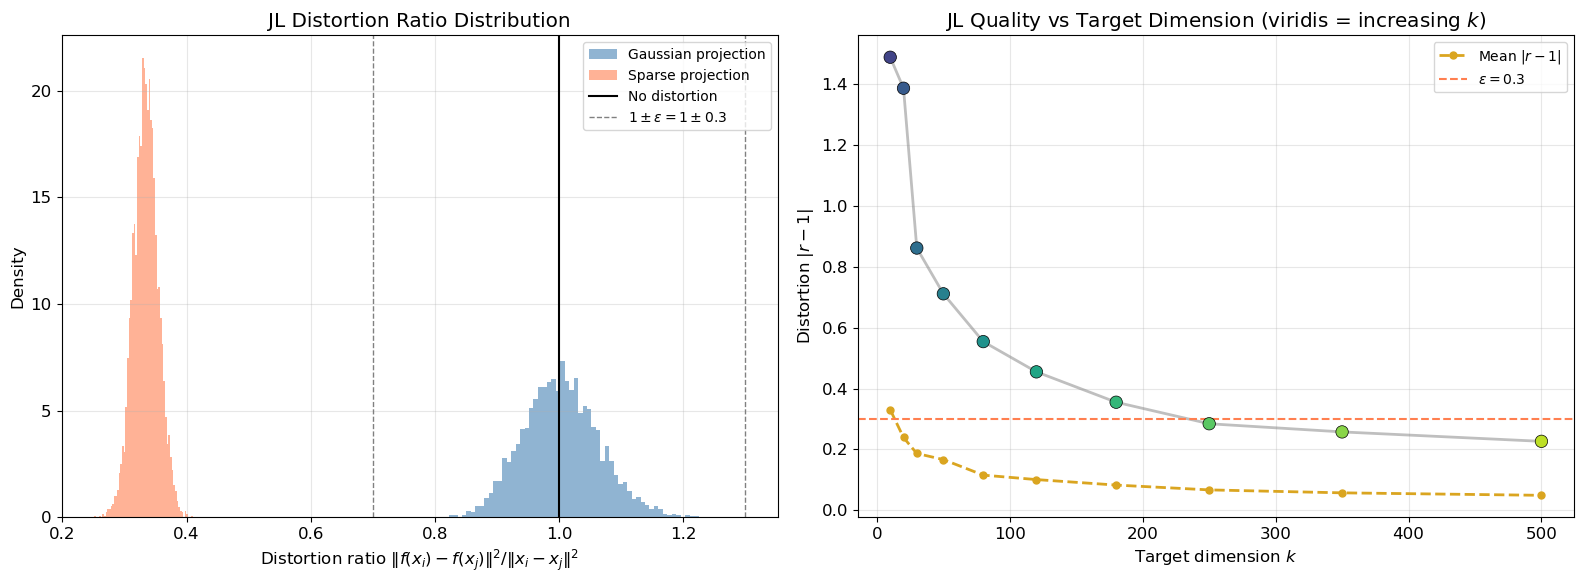

In [19]:
# =============================================================================
#  Panel 3: Distortion histogram & Evolution of JL quality with k
# =============================================================================
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Left: Distortion ratio histogram ----
ax = axes[0]
ax.hist(ratios_gauss, bins=60, density=True, alpha=0.6, color=C_PRIMARY,
        label='Gaussian projection')
ax.hist(ratios_sparse, bins=60, density=True, alpha=0.6, color=C_SECONDARY,
        label='Sparse projection')
ax.axvline(1.0, color='k', linewidth=1.5, linestyle='-', label='No distortion')
ax.axvline(1 - EPSILON_JL, color='gray', linewidth=1, linestyle='--')
ax.axvline(1 + EPSILON_JL, color='gray', linewidth=1, linestyle='--',
           label=f'$1 \\pm \\epsilon = 1 \\pm {EPSILON_JL}$')
ax.set_xlabel('Distortion ratio $\\|f(x_i)-f(x_j)\\|^2 / \\|x_i-x_j\\|^2$')
ax.set_ylabel('Density')
ax.set_title('JL Distortion Ratio Distribution')
ax.legend(fontsize=10)

# ---- Right: Max distortion vs k (evolution) ----
k_vals = np.array([10, 20, 30, 50, 80, 120, 180, 250, 350, 500])
max_distortions = []
mean_distortions = []

N_SUB_EVO = 60  # smaller subset for speed
for k in k_vals:
    X_p = jl_projection(X_jl[:N_SUB_EVO], k, method='gaussian')
    rats = distortion_ratio(X_jl[:N_SUB_EVO], X_p)
    max_distortions.append(np.max(np.abs(rats - 1.0)))
    mean_distortions.append(np.mean(np.abs(rats - 1.0)))

ax = axes[1]
cmap = plt.get_cmap(C_EVOLUTION)
colors_evo = cmap(np.linspace(0.2, 0.9, len(k_vals)))

ax.scatter(k_vals, max_distortions, c=colors_evo, s=80, zorder=5,
           edgecolors='k', linewidth=0.5)
ax.plot(k_vals, max_distortions, '-', color='gray', alpha=0.5)
ax.plot(k_vals, mean_distortions, 'o--', color=C_ACCENT, markersize=5,
        label='Mean $|r - 1|$')
ax.axhline(y=EPSILON_JL, color=C_SECONDARY, linestyle='--', linewidth=1.5,
           label=f'$\\epsilon = {EPSILON_JL}$')
ax.set_xlabel('Target dimension $k$')
ax.set_ylabel('Distortion $|r - 1|$')
ax.set_title('JL Quality vs Target Dimension (viridis = increasing $k$)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---

## 10. Extensions & Connections

This section briefly surveys advanced topics that build on the concentration
inequalities developed above.

### 10.1 Uniform Convergence & VC Dimension

Concentration inequalities for *single* quantities (sample mean, single
projection) generalise to **uniform** statements over function classes.

Let $\mathcal{F}$ be a class of functions $f : \mathcal{X} \to [0, 1]$. The
*empirical process* is:

$$\sup_{f \in \mathcal{F}} \left|\frac{1}{n}\sum_{i=1}^n f(X_i) - E[f(X)]\right|$$

By **symmetrisation** + **chaining**, this is bounded by the **Rademacher
complexity** $\mathcal{R}_n(\mathcal{F})$. For binary classifiers, the
Rademacher complexity is controlled by the **VC dimension** $d_{\mathrm{VC}}$:

$$\mathcal{R}_n(\mathcal{F}) \leq O\!\left(\sqrt{\frac{d_{\mathrm{VC}} \log n}{n}}\right)$$

This is the foundation of **statistical learning theory**.

### 10.2 PAC-Bayes Bounds

For a *distribution* $Q$ over hypotheses (rather than a single hypothesis),
**PAC-Bayes** bounds give:

$$E_{h \sim Q}[\text{true risk}] \leq E_{h \sim Q}[\text{empirical risk}] +
\sqrt{\frac{\text{KL}(Q \| P) + \log(n / \delta)}{2n}}$$

where $P$ is a data-independent *prior* distribution over hypotheses. The KL
divergence term replaces the VC dimension. PAC-Bayes bounds are often tighter
and more applicable to modern deep learning.

### 10.3 Martingale Concentration

When $X_1, \ldots, X_n$ are **not independent** but form a **martingale
difference sequence** ($E[X_i | X_1, \ldots, X_{i-1}] = 0$), analogues of
Hoeffding and Bernstein still hold:

- **Azuma-Hoeffding**: If $|X_i - X_{i-1}| \leq c_i$ a.s., then
  $P(S_n \geq t) \leq \exp\!\left(-t^2 / (2 \sum c_i^2)\right)$.

- **Freedman's inequality**: Variance-adaptive (Bernstein-type) for martingales.

Applications: adaptive algorithms, online learning, bandit problems.

### 10.4 Compressed Sensing & Restricted Isometry Property

The **Restricted Isometry Property (RIP)** states that a measurement matrix
$A \in \mathbb{R}^{m \times n}$ satisfies:

$$(1 - \delta_s) \|x\|^2 \leq \|Ax\|^2 \leq (1 + \delta_s) \|x\|^2$$

for all $s$-sparse vectors $x$. This is precisely a **JL-type guarantee**
restricted to sparse vectors.

By the matrix concentration results from Section 6, random Gaussian matrices
satisfy RIP with $m = O(s \log(n/s))$ measurements. This is the theoretical
foundation of **compressed sensing**: we can recover an $s$-sparse signal
$x \in \mathbb{R}^n$ from only $m \ll n$ linear measurements via $\ell_1$
minimisation (basis pursuit).

### Summary of Key Results

| Inequality | Tail Decay | Key Assumption |
|-----------|-----------|----------------|
| Markov | $O(1/t)$ | $X \geq 0$ |
| Chebyshev | $O(1/t^2)$ | Finite variance |
| Hoeffding | $e^{-Ct^2}$ | Bounded, independent |
| Bernstein | $e^{-Ct^2/(\sigma^2 + t)}$ | Bounded, independent, low variance |
| Sub-Gaussian | $e^{-Ct^2/\sigma^2}$ | MGF condition |
| Matrix Bernstein | $2d \cdot e^{-Ct^2/(\sigma^2 + t)}$ | Bounded matrix norm |
| JL Lemma | $e^{-Ck\epsilon^2}$ | Random projection |

In [20]:
# =============================================================================
#  Final summary: all verification results
# =============================================================================

print("=" * 70)
print("  VERIFICATION SUMMARY")
print("=" * 70)
print()
print(f"  1. Hoeffding: empirical tail <= bound ")
print(f"     max violation = {max_violation:.2e} [{status}]")
print()
print(f"  2. Bernstein tighter than Hoeffding for low-variance")
print(f"     max ratio (Hoeffding/Bernstein) = {ratio:.2e} [{status_bt}]")
print()
print(f"  3. JL distortion within (1 +/- {EPSILON_JL})")
print(f"     fraction OK = {frac_ok_gauss:.2e} [{status_jl}]")
print()
print(f"  4. Coverage probability >= 1 - delta")
print(f"     Hoeffding coverage = {coverage_hoeff:.2e} [{status_cov_h}]")
print(f"     Bernstein coverage = {coverage_bern:.2e} [{status_cov_b}]")
print()
print("=" * 70)

  VERIFICATION SUMMARY

  1. Hoeffding: empirical tail <= bound 
     max violation = -4.79e-06 [PASS]

  2. Bernstein tighter than Hoeffding for low-variance
     max ratio (Hoeffding/Bernstein) = 2.38e+06 [PASS]

  3. JL distortion within (1 +/- 0.3)
     fraction OK = 1.00e+00 [PASS]

  4. Coverage probability >= 1 - delta
     Hoeffding coverage = 1.00e+00 [PASS]
     Bernstein coverage = 1.00e+00 [PASS]

